<a href="https://colab.research.google.com/github/Yangel300/BreathIA/blob/main/weef1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas

In [ ]:
import os

# Clone the GitHub repository
!git clone https://github.com/SJTU-YONGFU-RESEARCH-GRP/SPRSound.git




fatal: destination path 'SPRSound' already exists and is not an empty directory.


In [ ]:
import pandas as pd
datapath="/content/SPRSound/Patient Summary/Grand_Challenge'23_patient_summary.csv"

data=pd.read_csv(datapath)

data


,patient_num,disease,age,gender
0,64634665,Bronchitis,3.3,M
1,00014365,Control group,4.3,F
2,40844382,Bronchitis,4.8,F
3,40876967,Bronchitis,4.3,M
4,40884475,Pneumonia (non-severe),3.8,F
...,...,...,...,...
89,66353843,Bronchitis,3.2,F
90,66365613,Control group,10.3,F
91,66366234,Bronchitis,3.8,F
92,66366279,Bronchitis,4.9,M


/tmp/ipykernel_18158/2179600789.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, y='disease', order=data['disease'].value_counts().index, palette='viridis')


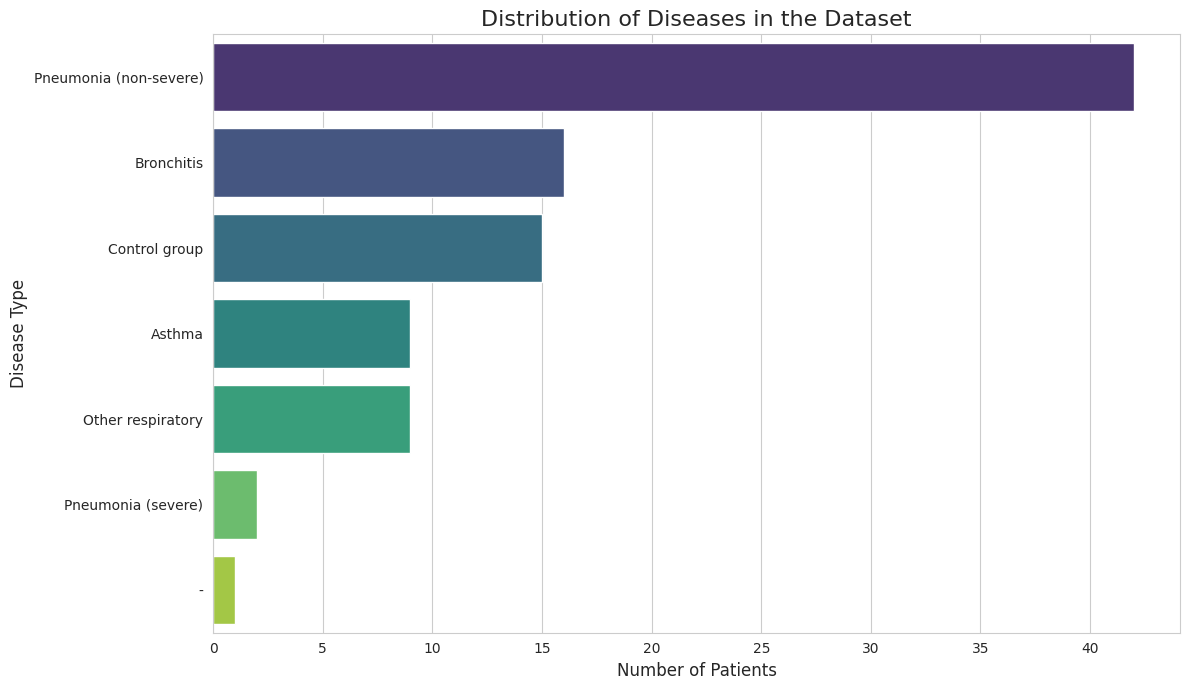

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plot
sns.set_style("whitegrid")

# Create the bar plot (acting as a histogram for categorical data)
plt.figure(figsize=(12, 7))
sns.countplot(data=data, y='disease', order=data['disease'].value_counts().index, palette='viridis')
plt.title('Distribution of Diseases in the Dataset', fontsize=16)
plt.xlabel('Number of Patients', fontsize=12)
plt.ylabel('Disease Type', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import os
import json
import librosa
import numpy as np

def slice_audio_with_annotations(audio_filepath, json_filepath):
  """
  Slices an audio file into segments based on event annotations from a JSON file.

  Args:
    audio_filepath (str): Path to the audio (.wav) file.
    json_filepath (str): Path to the corresponding JSON annotation file.

  Returns:
    list: A list of dictionaries, where each dictionary contains:
          - 'segment': The numpy array of the sliced audio segment.
          - 'event_type': The type of the event (e.g., 'Wheeze').
          - 'start_ms': Start time of the event in milliseconds.
          - 'end_ms': End time of the event in milliseconds.
  """
  try:
    with open(json_filepath, 'r') as f:
      json_data = json.load(f)
  except FileNotFoundError:
    print(f"JSON file not found: {json_filepath}")
    return []
  except json.JSONDecodeError:
    print(f"Error decoding JSON from file: {json_filepath}")
    return []

  try:
    y_full, sr_full = librosa.load(audio_filepath)
  except FileNotFoundError:
    print(f"Audio file not found: {audio_filepath}")
    return []
  except Exception as e:
    print(f"Error loading audio file {audio_filepath}: {e}")
    return []

  event_annotations = json_data.get('event_annotation', [])
  sliced_data = []

  for event in event_annotations:
    start_ms = int(event.get('start', 0))
    end_ms = int(event.get('end', 0))
    event_type = event.get('type', 'Unknown')

    start_time_s = start_ms / 1000.0
    end_time_s = end_ms / 1000.0

    start_sample = int(start_time_s * sr_full)
    end_sample = int(end_time_s * sr_full)

    # Ensure indices are within bounds
    start_sample = max(0, start_sample)
    end_sample = min(len(y_full), end_sample)

    if start_sample < end_sample:
      y_segment = y_full[start_sample:end_sample]
      sliced_data.append({
          'segment': y_segment,
          'event_type': event_type,
          'start_ms': start_ms,
          'end_ms': end_ms
      })
  return sliced_data

# Define all relevant folders using existing variables from the notebook state
wavtrainfolder1="/content/SPRSound/BioCAS2022/test2022_wav"
wavtrainfolder2="/content/SPRSound/BioCAS2022/train2022_wav"
wavtrainfolder3="/content/SPRSound/BioCAS2023/test2023_wav"
wavtrainfolder4="/content/SPRSound/BioCAS2024/test2024_wav"

wav_folders = [
    wavtrainfolder1,
    wavtrainfolder2,
    wavtrainfolder3,
    wavtrainfolder4
]

jsontrainfolder1="/content/SPRSound/BioCAS2022/test2022_json/inter_test_json"
jsontrainfolder2="/content/SPRSound/BioCAS2022/test2022_json/intra_test_json"
jsontrainfolder3="/content/SPRSound/BioCAS2022/train2022_json"
jsontrainfolder4="/content/SPRSound/BioCAS2023/test2023_json"
jsontrainfolder5="/content/SPRSound/BioCAS2024/test2024_json"
json_folder_mapping = {
    wavtrainfolder1: [jsontrainfolder1, jsontrainfolder2], # BioCAS2022/test2022_wav maps to inter_test_json and intra_test_json
    wavtrainfolder2: [jsontrainfolder3], # BioCAS2022/train2022_wav maps to train2022_json
    wavtrainfolder3: [jsontrainfolder4], # BioCAS2023/test2023_wav maps to test2023_json
    wavtrainfolder4: [jsontrainfolder5]  # BioCAS2024/test2024_wav maps to test2024_json
}

processed_audio_data = {}

# Iterate through each WAV folder
for wav_folder in wav_folders:
    print(f"Processing folder: {wav_folder}")
    for root, _, files in os.walk(wav_folder):
        for filename in files:
            if filename.endswith(".wav"):
                audio_base_filename = os.path.splitext(filename)[0]
                audio_filepath = os.path.join(root, filename)

                json_filepath = None
                # Check all potential JSON folders for the current wav_folder
                for json_candidate_folder in json_folder_mapping.get(wav_folder, []):
                    candidate_json_path = os.path.join(json_candidate_folder, audio_base_filename + ".json")
                    if os.path.exists(candidate_json_path):
                        json_filepath = candidate_json_path
                        break # Found the JSON file, no need to check other subfolders for this audio file

                if json_filepath:
                    print(f"  Slicing {filename} with annotation from {os.path.basename(json_filepath)}")
                    segments_with_annotations = slice_audio_with_annotations(audio_filepath, json_filepath)
                    if segments_with_annotations:
                        processed_audio_data[audio_base_filename] = segments_with_annotations
                    else:
                        print(f"    No segments found or error for {audio_base_filename}")
                else:
                    print(f"  No JSON annotation found for {filename} in specified JSON folders. Skipping.")

print("\nProcessing complete.")
print(f"Total unique audio files processed with annotations: {len(processed_audio_data)}")

# Display a sample of the processed data to verify
if processed_audio_data:
    sample_key = next(iter(processed_audio_data))
    print(f"\nSample of processed data for '{sample_key}':")
    for i, segment_info in enumerate(processed_audio_data[sample_key]):
        print(f"  Segment {i+1}: Type={segment_info['event_type']}, Start={segment_info['start_ms']}ms, End={segment_info['end_ms']}ms, Segment_shape={segment_info['segment'].shape}")
    print("\nNote: 'segment' contains numpy arrays, which are not fully printed for brevity.")
else:
    print("No audio data was processed.")

Streaming output truncated to the last 5000 lines.
  Slicing 41031554_10.7_0_p2_4076.wav with annotation from 41031554_10.7_0_p2_4076.json
  Slicing 65118898_0.7_0_p3_4168.wav with annotation from 65118898_0.7_0_p3_4168.json
  Slicing 41223618_1.0_0_p4_3611.wav with annotation from 41223618_1.0_0_p4_3611.json
  Slicing 41244654_0.6_0_p3_331.wav with annotation from 41244654_0.6_0_p3_331.json
  Slicing 41274453_4.3_1_p2_1406.wav with annotation from 41274453_4.3_1_p2_1406.json
  Slicing 40890405_3.3_0_p3_3686.wav with annotation from 40890405_3.3_0_p3_3686.json
  Slicing 40512331_8.1_1_p4_3547.wav with annotation from 40512331_8.1_1_p4_3547.json
  Slicing 64601539_5.3_1_p2_3505.wav with annotation from 64601539_5.3_1_p2_3505.json
  Slicing 41249093_4.2_1_p4_3855.wav with annotation from 41249093_4.2_1_p4_3855.json
  Slicing 65109516_0.2_0_p4_3657.wav with annotation from 65109516_0.2_0_p4_3657.json
  Slicing 41227367_6.9_1_p2_2782.wav with annotation from 41227367_6.9_1_p2_2782.json
  S

In [ ]:
processed_audio_data

{'64779933_1.3_0_p2_3818': [{'segment': array([-0.0016696 , -0.00168199, -0.00169   , ...,  0.00083829,
           0.00075356,  0.00066545], dtype=float32),
   'event_type': 'Wheeze',
   'start_ms': 54,
   'end_ms': 1186},
  {'segment': array([-0.00966714, -0.01125991, -0.01285374, ..., -0.00033754,
          -0.00037118, -0.00040454], dtype=float32),
   'event_type': 'Wheeze',
   'start_ms': 4577,
   'end_ms': 5693},
  {'segment': array([ 0.00064053,  0.00067538,  0.00071162, ..., -0.00107217,
          -0.00105783, -0.00104614], dtype=float32),
   'event_type': 'Wheeze',
   'start_ms': 6837,
   'end_ms': 7821},
  {'segment': array([0.00039546, 0.00039721, 0.00039599, ..., 0.00137598, 0.00170569,
          0.00204101], dtype=float32),
   'event_type': 'Wheeze',
   'start_ms': 8664,
   'end_ms': 9206},
  {'segment': array([2.4072633e-06, 2.9112109e-06, 4.1595501e-07, ..., 8.9599035e-04,
          8.8666897e-04, 8.7526778e-04], dtype=float32),
   'event_type': 'Wheeze',
   'start_ms': 2

In [ ]:
#Segundo dataset:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("vbookshelf/respiratory-sound-database")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'respiratory-sound-database' dataset.
Path to dataset files: /kaggle/input/respiratory-sound-database


In [ ]:
def slice_audio_from_txt_annotations(audio_filepath, txt_filepath):
  """
  Slices an audio file into segments based on event annotations from a TXT file.

  Args:
    audio_filepath (str): Path to the audio (.wav) file.
    txt_filepath (str): Path to the corresponding TXT annotation file.

  Returns:
    list: A list of dictionaries, where each dictionary contains:
          - 'segment': The numpy array of the sliced audio segment.
          - 'event_type': The type of the event (e.g., 'Wheeze', 'Crackle', 'Normal').
          - 'start_ms': Start time of the event in milliseconds.
          - 'end_ms': End time of the event in milliseconds.
  """
  sliced_data = []

  try:
    y_full, sr_full = librosa.load(audio_filepath)
  except FileNotFoundError:
    print(f"Audio file not found: {audio_filepath}")
    return []
  except Exception as e:
    print(f"Error loading audio file {audio_filepath}: {e}")
    return []

  try:
    with open(txt_filepath, 'r') as f:
      # Skip header if present, or read all lines and filter if needed
      lines = f.readlines()
  except FileNotFoundError:
    print(f"TXT file not found: {txt_filepath}")
    return []

  for line in lines:
    parts = line.strip().split('\t') # Split by tab character
    if len(parts) == 4:
      try:
        start_time_s = float(parts[0])
        end_time_s = float(parts[1])
        has_wheeze = int(parts[2])
        has_crackle = int(parts[3])

        event_type = 'Normal'
        if has_wheeze == 1 and has_crackle == 1:
          event_type = 'Wheeze+Crackle'
        elif has_wheeze == 1:
          event_type = 'Wheeze'
        elif has_crackle == 1:
          event_type = 'Crackle'

        start_ms = int(start_time_s * 1000)
        end_ms = int(end_time_s * 1000)

        start_sample = int(start_time_s * sr_full)
        end_sample = int(end_time_s * sr_full)

        # Ensure indices are within bounds
        start_sample = max(0, start_sample)
        end_sample = min(len(y_full), end_sample)

        if start_sample < end_sample:
          y_segment = y_full[start_sample:end_sample]
          sliced_data.append({
              'segment': y_segment,
              'event_type': event_type,
              'start_ms': start_ms,
              'end_ms': end_ms
          })
      except ValueError:
        print(f"Skipping malformed line in {txt_filepath}: {line.strip()}")
  return sliced_data

In [ ]:
# Path to the second dataset
second_dataset_path = '/kaggle/input/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files'
third_dataset_path = "/kaggle/input/respiratory-sound-database/respiratory_sound_database"
print(f"Processing second dataset: {second_dataset_path}")

# Iterate through the files in the directory
for root, _, files in os.walk(second_dataset_path):
    for filename in files:
        if filename.endswith('.wav'):
            audio_base_filename = os.path.splitext(filename)[0]
            audio_filepath = os.path.join(root, filename)
            txt_filepath = os.path.join(root, audio_base_filename + '.txt')

            if os.path.exists(txt_filepath):
                print(f"  Slicing {filename} with annotation from {os.path.basename(txt_filepath)}")
                segments_with_annotations = slice_audio_from_txt_annotations(audio_filepath, txt_filepath)
                if segments_with_annotations:
                    # Append to the existing processed_audio_data dictionary
                    # If a key already exists, this will overwrite it.
                    # If you want to merge, you might need a different structure.
                    processed_audio_data[audio_base_filename] = segments_with_annotations
                else:
                    print(f"    No segments found or error for {audio_base_filename}")
            else:
                print(f"  No TXT annotation found for {filename}. Skipping.")

print("\nSecond dataset processing complete.")
print(f"Total unique audio files processed including new dataset: {len(processed_audio_data)}")

print(f"Processing third dataset: {third_dataset_path}")

# Iterate through the files in the directory
for root, _, files in os.walk(third_dataset_path):
    for filename in files:
        if filename.endswith('.wav'):
            audio_base_filename = os.path.splitext(filename)[0]
            audio_filepath = os.path.join(root, filename)
            txt_filepath = os.path.join(root, audio_base_filename + '.txt')

            if os.path.exists(txt_filepath):
                print(f"  Slicing {filename} with annotation from {os.path.basename(txt_filepath)}")
                segments_with_annotations = slice_audio_from_txt_annotations(audio_filepath, txt_filepath)
                if segments_with_annotations:
                    # Append to the existing processed_audio_data dictionary
                    # If a key already exists, this will overwrite it.
                    # If you want to merge, you might need a different structure.
                    processed_audio_data[audio_base_filename] = segments_with_annotations
                else:
                    print(f"    No segments found or error for {audio_base_filename}")
            else:
                print(f"  No TXT annotation found for {filename}. Skipping.")

print("\nThird dataset processing complete.")
print(f"Total unique audio files processed including new dataset: {len(processed_audio_data)}")


# Display a sample of the processed data to verify
if processed_audio_data:
    sample_key = next(iter(processed_audio_data))
    print(f"\nSample of processed data for '{sample_key}':")
    for i, segment_info in enumerate(processed_audio_data[sample_key]):
        print(f"  Segment {i+1}: Type={segment_info['event_type']}, Start={segment_info['start_ms']}ms, End={segment_info['end_ms']}ms, Segment_shape={segment_info['segment'].shape}")
    print("\nNote: 'segment' contains numpy arrays, which are not fully printed for brevity.")
else:
    print("No audio data was processed.")

Processing second dataset: /kaggle/input/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files
  Slicing 162_1b2_Ar_mc_AKGC417L.wav with annotation from 162_1b2_Ar_mc_AKGC417L.txt
  Slicing 193_1b2_Pl_mc_AKGC417L.wav with annotation from 193_1b2_Pl_mc_AKGC417L.txt
  Slicing 138_2p2_Ll_mc_AKGC417L.wav with annotation from 138_2p2_Ll_mc_AKGC417L.txt
  Slicing 207_2b2_Ar_mc_AKGC417L.wav with annotation from 207_2b2_Ar_mc_AKGC417L.txt
  Slicing 176_2b3_Pr_mc_AKGC417L.wav with annotation from 176_2b3_Pr_mc_AKGC417L.txt
  Slicing 151_2p3_Ll_mc_AKGC417L.wav with annotation from 151_2p3_Ll_mc_AKGC417L.txt
  Slicing 215_1b2_Ar_sc_Meditron.wav with annotation from 215_1b2_Ar_sc_Meditron.txt
  Slicing 210_1b1_Ar_sc_Meditron.wav with annotation from 210_1b1_Ar_sc_Meditron.txt
  Slicing 156_8b3_Pl_mc_AKGC417L.wav with annotation from 156_8b3_Pl_mc_AKGC417L.txt
  Slicing 140_2b3_Tc_mc_LittC2SE.wav with annotation from 140_2b3_Tc_mc_LittC2SE.txt
  Slicin

In [ ]:
processed_audio_data

{'64779933_1.3_0_p2_3818': [{'segment': array([-0.0016696 , -0.00168199, -0.00169   , ...,  0.00083829,
           0.00075356,  0.00066545], dtype=float32),
   'event_type': 'Wheeze',
   'start_ms': 54,
   'end_ms': 1186},
  {'segment': array([-0.00966714, -0.01125991, -0.01285374, ..., -0.00033754,
          -0.00037118, -0.00040454], dtype=float32),
   'event_type': 'Wheeze',
   'start_ms': 4577,
   'end_ms': 5693},
  {'segment': array([ 0.00064053,  0.00067538,  0.00071162, ..., -0.00107217,
          -0.00105783, -0.00104614], dtype=float32),
   'event_type': 'Wheeze',
   'start_ms': 6837,
   'end_ms': 7821},
  {'segment': array([0.00039546, 0.00039721, 0.00039599, ..., 0.00137598, 0.00170569,
          0.00204101], dtype=float32),
   'event_type': 'Wheeze',
   'start_ms': 8664,
   'end_ms': 9206},
  {'segment': array([2.4072633e-06, 2.9112109e-06, 4.1595501e-07, ..., 8.9599035e-04,
          8.8666897e-04, 8.7526778e-04], dtype=float32),
   'event_type': 'Wheeze',
   'start_ms': 2

Event Type Counts:
- Normal: 20239
- Wheeze: 3064
- Fine Crackle: 1645
- Crackle: 886
- Wheeze+Crackle: 548
- Rhonchi: 210
- Coarse Crackle: 112
- Stridor: 66


/tmp/ipykernel_4381/640812246.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Event Type', data=plot_data.sort_values(by='Count', ascending=False), palette='viridis')


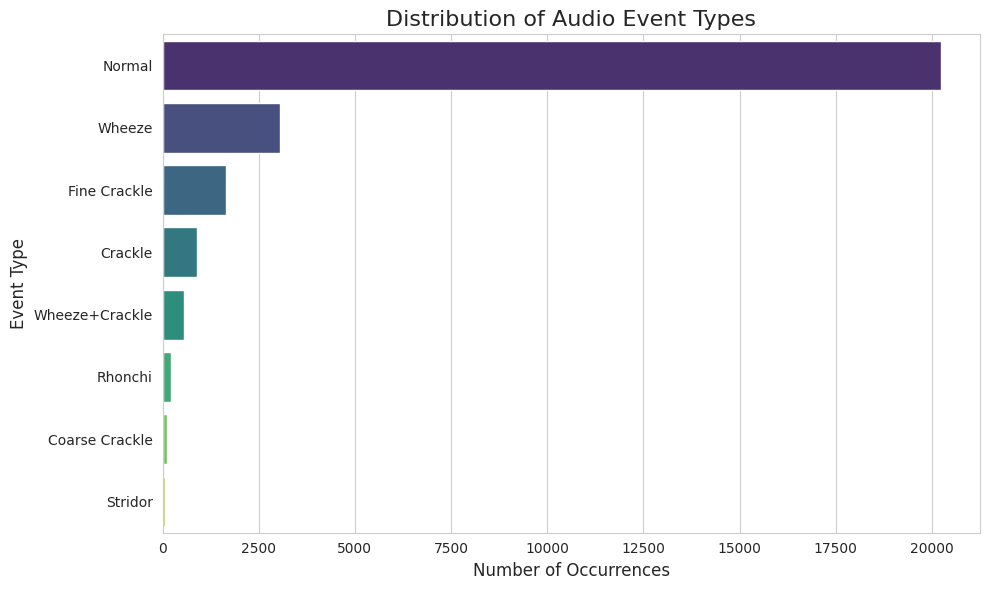

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialize a counter for event types
event_type_counts = Counter()

# Iterate through the processed_audio_data to collect all event types
for audio_file_name, segments in processed_audio_data.items():
    for segment_info in segments:
        event_type_counts[segment_info['event_type']] += 1

print("Event Type Counts:")
for event_type, count in event_type_counts.most_common():
    print(f"- {event_type}: {count}")

# Prepare data for plotting
plot_data = pd.DataFrame(event_type_counts.items(), columns=['Event Type', 'Count'])

# Create the histogram (bar plot for categorical data)
plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Event Type', data=plot_data.sort_values(by='Count', ascending=False), palette='viridis')
plt.title('Distribution of Audio Event Types', fontsize=16)
plt.xlabel('Number of Occurrences', fontsize=12)
plt.ylabel('Event Type', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import librosa
import numpy as np
import random
import copy


def augment_audio_segment(segment, sr, max_augmentations=3):
    """
    Aplica random augmentation por elemento de audio individual, igualando las muestras inferiores.
    """
    augmented_segment = segment.copy() # Copia del segmento a aumentar
    num_augmentations = random.randint(1, max_augmentations) # Aplica un valor de aumento entre 1 y max_augmentations

    augmentation_types = [
        'add_noise',
        'pitch_shift',
        'time_stretch'
    ] # Decía que eran las más usadas
    random.shuffle(augmentation_types)

    for i in range(num_augmentations):
        aug_type = augmentation_types[i % len(augmentation_types)] # Cycle through types

        if aug_type == 'add_noise':
            # Random Gaussian noise
            noise_amplitude = 0.005 * random.uniform(0.5, 2.0)
            augmented_segment += noise_amplitude * np.random.randn(len(augmented_segment))
        elif aug_type == 'pitch_shift':
            # Pitch shift with semitones
            n_steps = random.uniform(-1, 1) # -1 a 1 para que sea bajo
            augmented_segment = librosa.effects.pitch_shift(y=augmented_segment, sr=sr, n_steps=n_steps)
        elif aug_type == 'time_stretch':
            # Time stretch with a random rate.
            rate = random.uniform(0.9, 1.1) # Cambio de 20% (stretch)

            # Ensure the segment is long enough for STFT if it's too short for default n_fft
            if len(augmented_segment) < sr // 5: # Example threshold: 0.2 seconds
                # Pad short segments to prevent errors with time_stretch (evitaba errores)
                pad_length = sr // 5 - len(augmented_segment)
                augmented_segment = np.pad(augmented_segment, (0, pad_length), 'constant')
            augmented_segment = librosa.effects.time_stretch(y=augmented_segment, rate=rate)

    return augmented_segment

# Convertir processed_audio_data en una lista de diccionarios por segmento
all_segments_list = []
for audio_file_name, segments in processed_audio_data.items():
    for segment_info in segments:
        all_segments_list.append(segment_info)

# COntar los segmentos originales
final_segments_list = list(all_segments_list)

current_event_counts_flat = Counter(seg['event_type'] for seg in final_segments_list)

print("Cantidad de eventos original:")
for event_type, count in current_event_counts_flat.most_common():
    print(f"- {event_type}: {count}")

Cantidad de eventos original:
- Normal: 20239
- Wheeze: 3064
- Fine Crackle: 1645
- Crackle: 886
- Wheeze+Crackle: 548
- Rhonchi: 210
- Coarse Crackle: 112
- Stridor: 66


In [ ]:
arget_count = 4000 # Definición del número final, se dejó en 4000 considerando la cantidad de muestras de la clase "Normal"

# Establecer clases que requieren augmentation (todas menos "Normal")
classes_to_augment = ['Wheeze', 'Fine Crackle', 'Coarse Crackle', 'Rhonchi', 'Wheeze+Crackle', 'Stridor', 'Crackle']
print(f"Clases a aumentar: {classes_to_augment}")

# Recopilar segmentos por tipo de evento para el muestreo a partir de la lista
segments_by_event_type_flat = {event_type: [] for event_type in current_event_counts_flat.keys()}
for segment_info in final_segments_list:
    segments_by_event_type_flat[segment_info['event_type']].append(segment_info)

augmented_segments_count = 0
# sr_full = 22050 pero depende de las anteriores celdas

for event_type in classes_to_augment:
    current_count = current_event_counts_flat[event_type]
    segments_for_type = segments_by_event_type_flat[event_type]

    needed_samples = target_count - current_count
    print(f"Aumentando {event_type}: Se requieren {needed_samples} samples.")

    for _ in range(needed_samples):
        original_segment_info = random.choice(segments_for_type)
        original_segment = original_segment_info['segment']

        # Aplicar augmentation
        augmented_wav = augment_audio_segment(original_segment, sr=sr_full)

        # Crear un nuevo segmento (no sé si sea necesario)
        # Mantener datos originales
        augmented_segment_info = {
            'segment': augmented_wav,
            'event_type': original_segment_info['event_type'],
            'start_ms': original_segment_info['start_ms'],
            'end_ms': original_segment_info['end_ms']
        }
        final_segments_list.append(augmented_segment_info)
        augmented_segments_count += 1

print(f"\nTotal augmented segments added: {augmented_segments_count}")

# Volver a calcular cantidad de eventos
post_augmentation_counts = Counter(seg['event_type'] for seg in final_segments_list)

print("\nEvent Type Counts After Augmentation:")
for event_type, count in post_augmentation_counts.most_common():
    print(f"- {event_type}: {count}")

Clases a aumentar: ['Wheeze', 'Fine Crackle', 'Coarse Crackle', 'Rhonchi', 'Wheeze+Crackle', 'Stridor', 'Crackle']


NameError: name 'current_event_counts_flat' is not defined

In [ ]:
# Plot final
plot_data_augmented = pd.DataFrame(post_augmentation_counts.items(), columns=['Event Type', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Event Type', data=plot_data_augmented.sort_values(by='Count', ascending=False), palette='viridis')
plt.title('Distribution of Audio Event Types After Augmentation', fontsize=16)
plt.xlabel('Number of Occurrences', fontsize=12)
plt.ylabel('Event Type', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# ¿Hacemos data undersampling?

#Background

In [ ]:
import json

json_file_test="/content/SPRSound/BioCAS2022/test2022_json/inter_test_json/65118898_0.7_0_p1_4170.json"

# Open and load the JSON file
with open(json_file_test, 'r') as f:
    json_data = json.load(f)

# Print the content of the JSON file
print(json.dumps(json_data, indent=4))

{
    "record_annotation": "CAS",
    "event_annotation": [
        {
            "start": "29",
            "end": "437",
            "type": "Wheeze"
        },
        {
            "start": "964",
            "end": "1340",
            "type": "Wheeze"
        },
        {
            "start": "1787",
            "end": "2175",
            "type": "Wheeze"
        },
        {
            "start": "2579",
            "end": "2948",
            "type": "Wheeze"
        },
        {
            "start": "3326",
            "end": "3783",
            "type": "Wheeze"
        },
        {
            "start": "4324",
            "end": "4967",
            "type": "Wheeze"
        },
        {
            "start": "5537",
            "end": "6360",
            "type": "Wheeze"
        },
        {
            "start": "7041",
            "end": "7907",
            "type": "Wheeze"
        }
    ]
}


### Key Features from JSON Data

In [ ]:
# Extracting record annotation
record_annotation = json_data.get('record_annotation')
print(f"Record Annotation: {record_annotation}")

# Extracting event annotations
event_annotations = json_data.get('event_annotation', [])
print(f"Number of Events: {len(event_annotations)}")

# Get unique event types and their counts
event_types = [event.get('type') for event in event_annotations]
from collections import Counter
event_type_counts = Counter(event_types)
print("Event Type Counts:")
for event_type, count in event_type_counts.items():
    print(f"- {event_type}: {count}")

# Calculate duration for each event and total duration
total_duration = 0
print("Event Durations:")
for i, event in enumerate(event_annotations):
    start = int(event.get('start', 0))
    end = int(event.get('end', 0))
    duration = end - start
    print(f"- Event {i+1} (Type: {event.get('type')}): Start={start}, End={end}, Duration={duration}")
    total_duration += duration

print(f"Total Duration of all Events: {total_duration}")

Record Annotation: CAS
Number of Events: 8
Event Type Counts:
- Wheeze: 8
Event Durations:
- Event 1 (Type: Wheeze): Start=29, End=437, Duration=408
- Event 2 (Type: Wheeze): Start=964, End=1340, Duration=376
- Event 3 (Type: Wheeze): Start=1787, End=2175, Duration=388
- Event 4 (Type: Wheeze): Start=2579, End=2948, Duration=369
- Event 5 (Type: Wheeze): Start=3326, End=3783, Duration=457
- Event 6 (Type: Wheeze): Start=4324, End=4967, Duration=643
- Event 7 (Type: Wheeze): Start=5537, End=6360, Duration=823
- Event 8 (Type: Wheeze): Start=7041, End=7907, Duration=866
Total Duration of all Events: 4330


In [ ]:
record_annotation = json_data.get('record_annotation')
event_annotations= json_data.get('event_annotation', [])
print(f"Event Annotation: {event_annotations}")
number_of_events=len(event_annotations)

for i in range(number_of_events):
  event_type=event_annotations[i].get('type')
  event_start=event_annotations[i].get('start')
  event_end=event_annotations[i].get("end")
  print(event_type,event_start,event_end)

Event Annotation: [{'start': '29', 'end': '437', 'type': 'Wheeze'}, {'start': '964', 'end': '1340', 'type': 'Wheeze'}, {'start': '1787', 'end': '2175', 'type': 'Wheeze'}, {'start': '2579', 'end': '2948', 'type': 'Wheeze'}, {'start': '3326', 'end': '3783', 'type': 'Wheeze'}, {'start': '4324', 'end': '4967', 'type': 'Wheeze'}, {'start': '5537', 'end': '6360', 'type': 'Wheeze'}, {'start': '7041', 'end': '7907', 'type': 'Wheeze'}]
Wheeze 29 437
Wheeze 964 1340
Wheeze 1787 2175
Wheeze 2579 2948
Wheeze 3326 3783
Wheeze 4324 4967
Wheeze 5537 6360
Wheeze 7041 7907


In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
def graph_audio(audio="audio", colorx="blue",y=None, sr=None):
  if y is None and sr is None:
    y,sr=librosa.load(audio)
  y=y/np.max(np.abs(y))
  dt=y.size/sr
  plt.figure(figsize=(3.8, 2.8))
  plt.subplot()
  plt.grid()
  plt.xlim(0,dt)
  plt.ylim(-1.1,1.1)
  librosa.display.waveshow(y, sr=sr, color=colorx)
  plt.xlabel('tiempo [s]')
  plt.ylabel('amplitud[/]')
  return y,22050,dt

<Figure size 800x400 with 0 Axes>

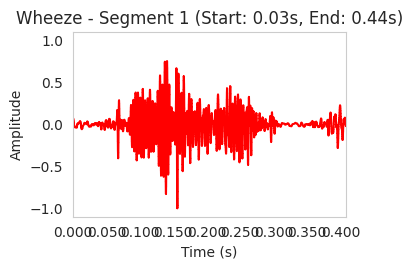

<Figure size 800x400 with 0 Axes>

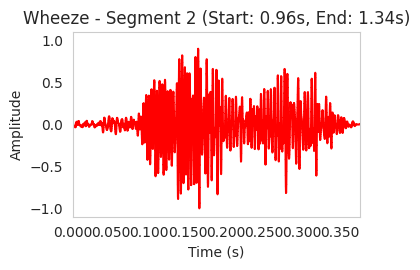

<Figure size 800x400 with 0 Axes>

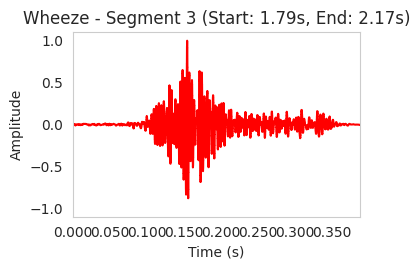

<Figure size 800x400 with 0 Axes>

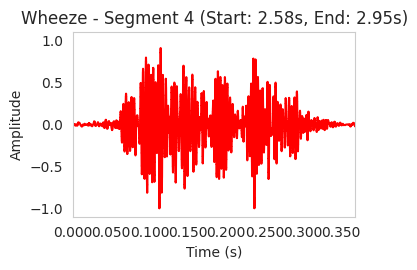

<Figure size 800x400 with 0 Axes>

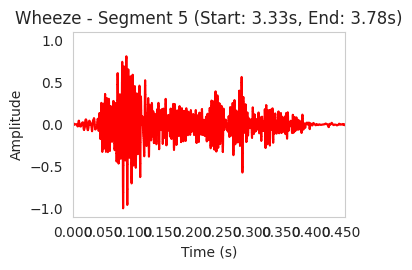

<Figure size 800x400 with 0 Axes>

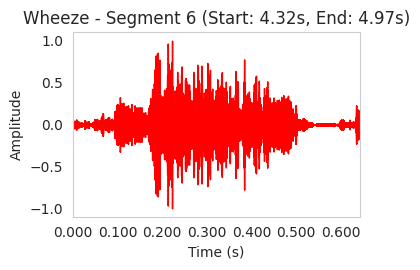

<Figure size 800x400 with 0 Axes>

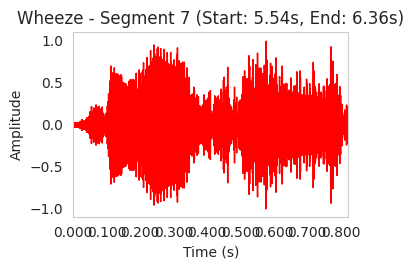

<Figure size 800x400 with 0 Axes>

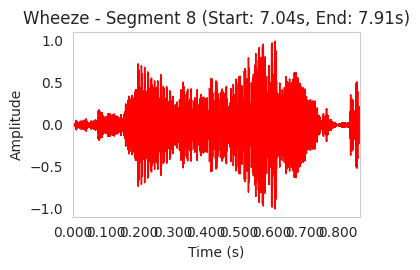

In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

audio_path = "/content/SPRSound/BioCAS2022/test2022_wav/65118898_0.7_0_p1_4170.wav"

# Load the full audio file
y_full, sr_full = librosa.load(audio_path)

# Assuming event_annotations is already loaded from the JSON data
# and contains dictionaries like {'start': '29', 'end': '437', 'type': 'Wheeze'}

# Iterate through each event and plot its segment
for i, event in enumerate(event_annotations):
    event_type = event.get('type', 'Unknown Event')
    start_ms = int(event.get('start', 0))
    end_ms = int(event.get('end', 0))

    # Convert milliseconds to seconds
    start_s = start_ms / 1000.0
    end_s = end_ms / 1000.0

    # Convert seconds to sample indices
    start_sample = int(start_s * sr_full)
    end_sample = int(end_s * sr_full)

    # Extract the audio segment
    y_segment = y_full[start_sample:end_sample]

    # Plot the segment using the graph_audio function
    # graph_audio expects y and sr directly if audio argument is not a path
    plt.figure(figsize=(8, 4))
    # Call the helper function for plotting
    graph_audio(y=y_segment, sr=sr_full, colorx='red')
    plt.title(f'{event_type} - Segment {i+1} (Start: {start_s:.2f}s, End: {end_s:.2f}s)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    plt.show()

In [ ]:
def slice_audio(audio="audio"):
  audio_path=f"{audio}.wav"
  json_path=f"/content/SPRSound/BioCAS2022/test2022_json/inter_test_json/65118898_0.7_0_p1_4170.json"
  with open(json_path, 'r') as f:
    json_data = json.load(f)
  y_full, sr_full = librosa.load(audio_path)
  event_annotations= json_data.get('event_annotation', [])
  sliced_audios=[]
  for event in event_annotations:
    start_time=int(event.get('start'))/1000
    end_time=int(event.get('end'))/1000
    start_sample = int(start_time * sr_full)
    end_sample = int(end_time * sr_full)
    y_segment = y_full[start_sample:end_sample]
    sliced_audios.append(y_segment)
  return sliced_audios



In [ ]:
y_full, sr_full = librosa.load("/content/SPRSound/BioCAS2022/test2022_wav/65118898_0.7_0_p1_4170.wav")
json_path=f"/content/SPRSound/BioCAS2022/test2022_json/inter_test_json/65118898_0.7_0_p1_4170.json"
with open(json_path, 'r') as f:
  json_data = json.load(f)
event_annotations= json_data.get('event_annotation', [])
for event in event_annotations:
  start_time=int(event.get('start'))/1000
  end_time=int(event.get('end'))/1000
  start_sample = int(start_time * sr_full)
  end_sample = int(end_time * sr_full)
  print(start_sample,end_sample)

639 9635
21256 29547
39403 47958
56866 65003
73338 83415
95344 109522
122090 140238
155254 174349


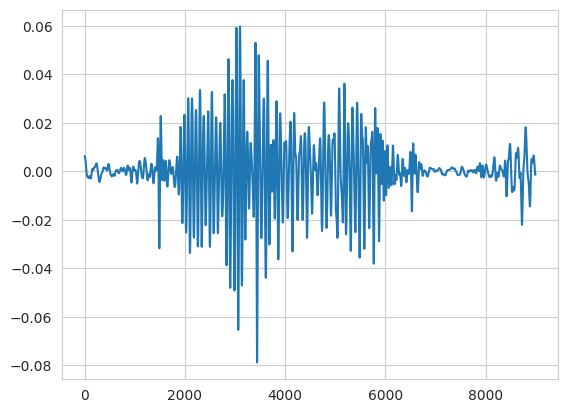

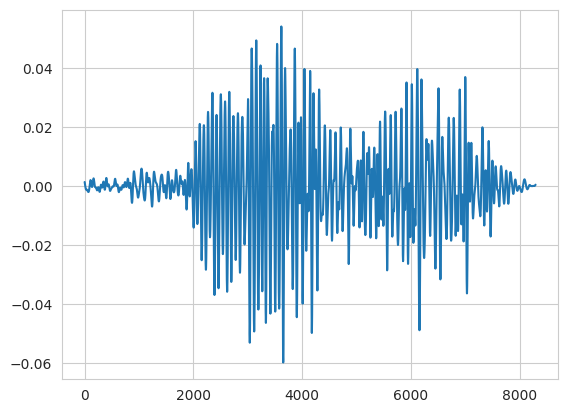

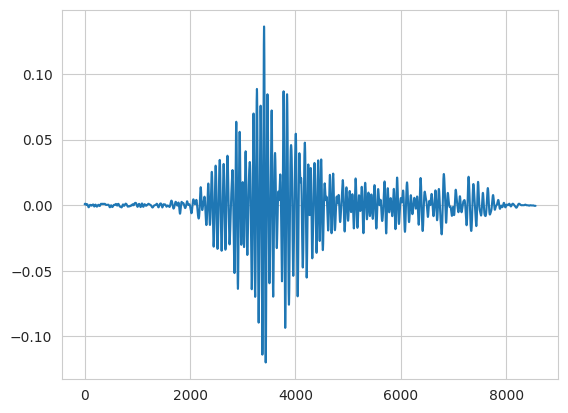

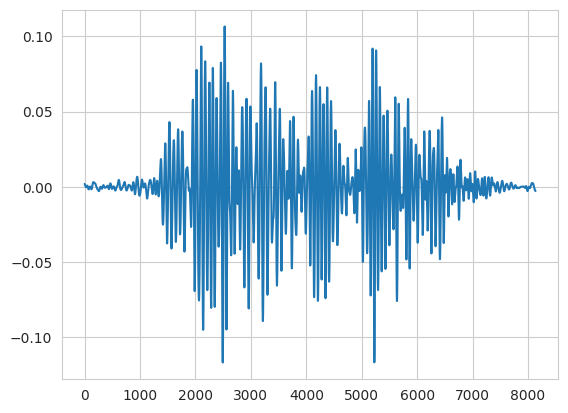

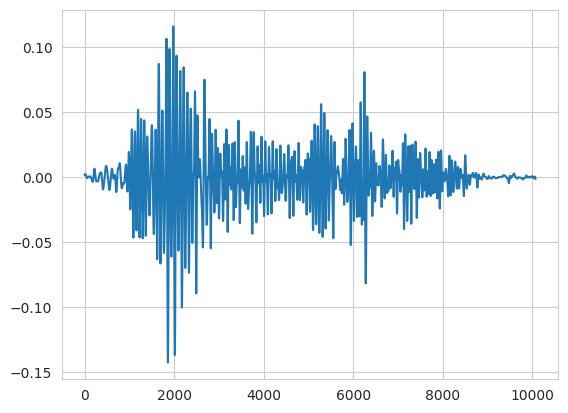

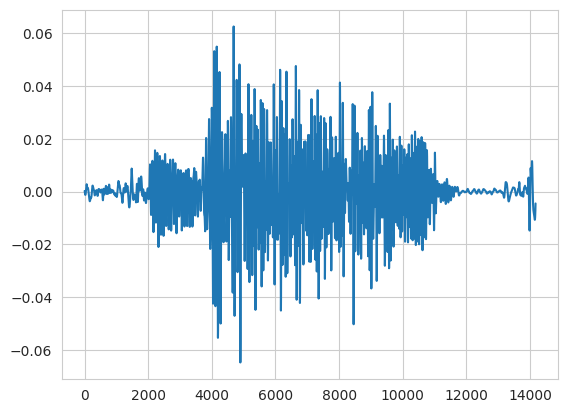

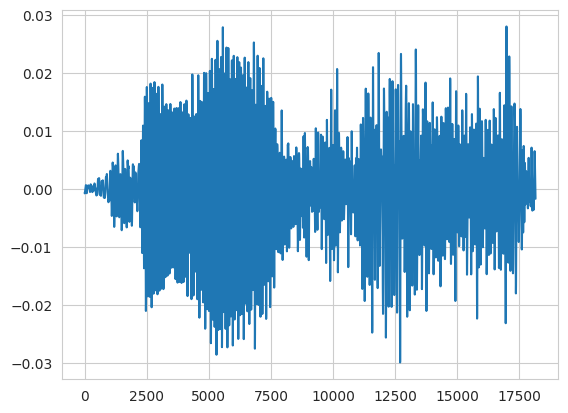

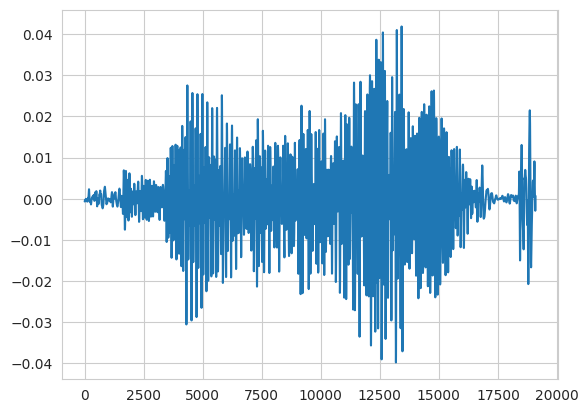

In [ ]:
a=slice_audio("/content/SPRSound/BioCAS2022/test2022_wav/65118898_0.7_0_p1_4170")
for i in a:
  plt.plot(i)
  plt.show()